In [5]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_gaussian_quantiles
# Construct dataset
# Gaussian 1
X1, y1 = make_gaussian_quantiles(cov=3.,
                                 n_samples=1000, n_features=2,
                                 n_classes=2, random_state=1)
X1 = pd.DataFrame(X1,columns=['x','y'])
y1 = pd.Series(y1)
# Gaussian 2
X2, y2 = make_gaussian_quantiles(mean=(4, 4), cov=1,
                                 n_samples=500, n_features=2,
                                 n_classes=2, random_state=1)
X2 = pd.DataFrame(X2,columns=['x','y'])
y2 = pd.Series(y2)
# Combine the gaussians
X1.shape
X2.shape
df = pd.DataFrame(np.concatenate((X1, X2)))
y = pd.Series(np.concatenate((y1, - y2 + 1)))

In [6]:
df['y'] = y

In [12]:
df['y'].value_counts()

y
1    500
0    500
Name: count, dtype: int64

In [8]:
df = df.sample(1500)[0:1000]

In [13]:
import matplotlib.pyplot as plt

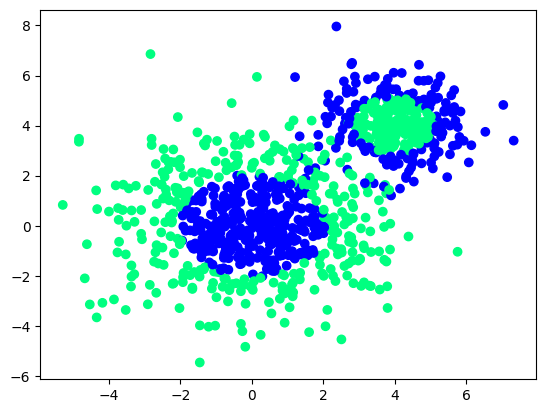

In [15]:
plt.scatter(df.iloc[:,0],df.iloc[:,1],c=df.iloc[:,-1],cmap='winter')

In [16]:
# Log of the odds
df['pre1'] = np.log(467/500)

In [17]:
np.log(494/500)

np.float64(-0.012072581234269249)

In [18]:
df

,0,1,y,pre1
1126,3.553301,4.204377,1,-0.068279
408,0.245329,-4.358366,1,-0.068279
534,-1.369706,2.119549,1,-0.068279
1134,6.137828,3.214466,0,-0.068279
110,1.314290,1.532707,0,-0.068279
...,...,...,...,...
1395,4.310272,1.905752,0,-0.068279
1424,4.853281,3.586971,1,-0.068279
1276,5.407540,4.129102,0,-0.068279
846,-0.463996,0.918603,0,-0.068279


In [19]:
# Calculate probability

p =np.exp(-0.024001)/(1+np.exp(-0.024001))

In [20]:
p

np.float64(0.4940000380194102)

In [21]:
df['pred1'] = 0.5

In [22]:
df

,0,1,y,pre1,pred1
1126,3.553301,4.204377,1,-0.068279,0.5
408,0.245329,-4.358366,1,-0.068279,0.5
534,-1.369706,2.119549,1,-0.068279,0.5
1134,6.137828,3.214466,0,-0.068279,0.5
110,1.314290,1.532707,0,-0.068279,0.5
...,...,...,...,...,...
1395,4.310272,1.905752,0,-0.068279,0.5
1424,4.853281,3.586971,1,-0.068279,0.5
1276,5.407540,4.129102,0,-0.068279,0.5
846,-0.463996,0.918603,0,-0.068279,0.5


In [23]:
df['res1'] = df['y'] - df['pre1']

In [24]:
df

,0,1,y,pre1,pred1,res1
1126,3.553301,4.204377,1,-0.068279,0.5,1.068279
408,0.245329,-4.358366,1,-0.068279,0.5,1.068279
534,-1.369706,2.119549,1,-0.068279,0.5,1.068279
1134,6.137828,3.214466,0,-0.068279,0.5,0.068279
110,1.314290,1.532707,0,-0.068279,0.5,0.068279
...,...,...,...,...,...,...
1395,4.310272,1.905752,0,-0.068279,0.5,0.068279
1424,4.853281,3.586971,1,-0.068279,0.5,1.068279
1276,5.407540,4.129102,0,-0.068279,0.5,0.068279
846,-0.463996,0.918603,0,-0.068279,0.5,0.068279


In [25]:
from sklearn.tree import DecisionTreeRegressor

In [26]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=4)

In [31]:
tree1.fit(df.iloc[:,0:2],df.iloc[:,-1])

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

[Text(0.4, 0.875, 'x[0] <= -1.865\nsquared_error = 0.25\nsamples = 1000\nvalue = 0.568'),
 Text(0.2, 0.625, 'squared_error = 0.029\nsamples = 100\nvalue = 1.038'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[0] <= 1.863\nsquared_error = 0.247\nsamples = 900\nvalue = 0.516'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[1] <= -1.819\nsquared_error = 0.205\nsamples = 478\nvalue = 0.357'),
 Text(0.2, 0.125, 'squared_error = 0.033\nsamples = 59\nvalue = 1.034'),
 Text(0.6, 0.125, 'squared_error = 0.156\nsamples = 419\nvalue = 0.262'),
 Text(0.8, 0.375, 'squared_error = 0.234\nsamples = 422\nvalue = 0.696')]

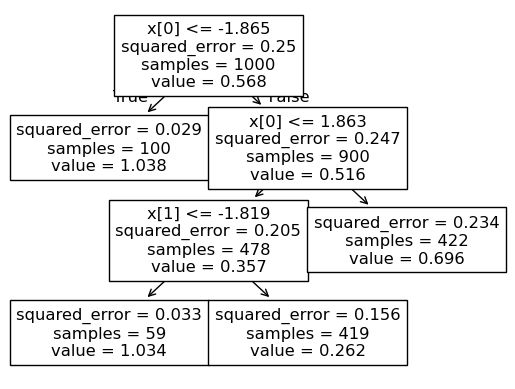

In [32]:
from sklearn.tree import plot_tree
plot_tree(tree1)

In [33]:
df['leaf_index1'] = tree1.apply(df.iloc[:,0:2])

In [34]:
df

,0,1,y,pre1,pred1,res1,leaf_index1
1126,3.553301,4.204377,1,-0.068279,0.5,1.068279,4
408,0.245329,-4.358366,1,-0.068279,0.5,1.068279,5
534,-1.369706,2.119549,1,-0.068279,0.5,1.068279,6
1134,6.137828,3.214466,0,-0.068279,0.5,0.068279,4
110,1.314290,1.532707,0,-0.068279,0.5,0.068279,6
...,...,...,...,...,...,...,...
1395,4.310272,1.905752,0,-0.068279,0.5,0.068279,4
1424,4.853281,3.586971,1,-0.068279,0.5,1.068279,4
1276,5.407540,4.129102,0,-0.068279,0.5,0.068279,4
846,-0.463996,0.918603,0,-0.068279,0.5,0.068279,6


In [35]:
df['leaf_index1'].value_counts()

leaf_index1
4    422
6    419
1    100
5     59
Name: count, dtype: int64

In [36]:
tree1.tree_.node_count

7

In [37]:
from sklearn.tree import plot_tree

[Text(0.4, 0.875, 'x[0] <= -1.865\nsquared_error = 0.25\nsamples = 1000\nvalue = 0.568'),
 Text(0.2, 0.625, 'squared_error = 0.029\nsamples = 100\nvalue = 1.038'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[0] <= 1.863\nsquared_error = 0.247\nsamples = 900\nvalue = 0.516'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[1] <= -1.819\nsquared_error = 0.205\nsamples = 478\nvalue = 0.357'),
 Text(0.2, 0.125, 'squared_error = 0.033\nsamples = 59\nvalue = 1.034'),
 Text(0.6, 0.125, 'squared_error = 0.156\nsamples = 419\nvalue = 0.262'),
 Text(0.8, 0.375, 'squared_error = 0.234\nsamples = 422\nvalue = 0.696')]

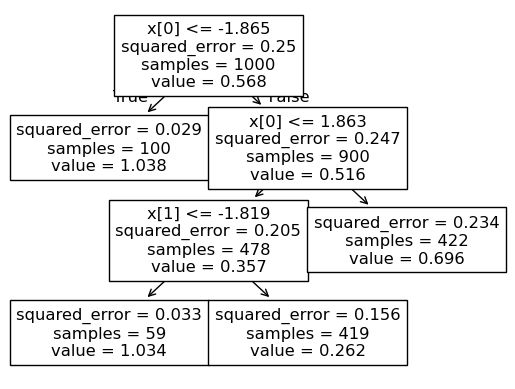

In [38]:
plot_tree(tree1)

In [40]:
df

,0,1,y,pre1,pred1,res1,leaf_index1
1126,3.553301,4.204377,1,-0.068279,0.5,1.068279,4
408,0.245329,-4.358366,1,-0.068279,0.5,1.068279,5
534,-1.369706,2.119549,1,-0.068279,0.5,1.068279,6
1134,6.137828,3.214466,0,-0.068279,0.5,0.068279,4
110,1.314290,1.532707,0,-0.068279,0.5,0.068279,6
...,...,...,...,...,...,...,...
1395,4.310272,1.905752,0,-0.068279,0.5,0.068279,4
1424,4.853281,3.586971,1,-0.068279,0.5,1.068279,4
1276,5.407540,4.129102,0,-0.068279,0.5,0.068279,4
846,-0.463996,0.918603,0,-0.068279,0.5,0.068279,6


In [44]:
df['leaf_index1'].value_counts().index

Index([4, 6, 1, 5], dtype='int64', name='leaf_index1')

In [47]:
num6 = df[df['leaf_index1'] == 6]['res1'].sum()

In [48]:
den6 = sum(df[df['leaf_index1'] == 6]['pre1'] * (1 - df[df['leaf_index1'] == 6]['pre1']))

In [49]:
num6

np.float64(109.60883427563033)

In [50]:
round(num6/den6,2)

np.float64(-3.59)

In [51]:
def return_logs(leaf):
  num = df[df['leaf_index1'] == leaf]['res1'].sum()
  den = sum(df[df['leaf_index1'] == leaf]['pre1'] * (1 - df[df['leaf_index1'] == leaf]['pre1']))
  return round(num/den,2)

In [52]:
df['log1'] = df['leaf_index1'].apply(return_logs)

In [53]:
df

,0,1,y,pre1,pred1,res1,leaf_index1,log1
1126,3.553301,4.204377,1,-0.068279,0.5,1.068279,4,-9.55
408,0.245329,-4.358366,1,-0.068279,0.5,1.068279,5,-14.18
534,-1.369706,2.119549,1,-0.068279,0.5,1.068279,6,-3.59
1134,6.137828,3.214466,0,-0.068279,0.5,0.068279,4,-9.55
110,1.314290,1.532707,0,-0.068279,0.5,0.068279,6,-3.59
...,...,...,...,...,...,...,...,...
1395,4.310272,1.905752,0,-0.068279,0.5,0.068279,4,-9.55
1424,4.853281,3.586971,1,-0.068279,0.5,1.068279,4,-9.55
1276,5.407540,4.129102,0,-0.068279,0.5,0.068279,4,-9.55
846,-0.463996,0.918603,0,-0.068279,0.5,0.068279,6,-3.59


In [54]:
df['pre2'] = -0.024 + df['log1']

In [55]:
df['pre2'] = np.exp(df['pre2'])/(1 + np.exp(df['pre2']))

In [56]:
df

,0,1,y,pre1,pred1,res1,leaf_index1,log1,pre2
1126,3.553301,4.204377,1,-0.068279,0.5,1.068279,4,-9.55,6.950794e-05
408,0.245329,-4.358366,1,-0.068279,0.5,1.068279,5,-14.18,6.780799e-07
534,-1.369706,2.119549,1,-0.068279,0.5,1.068279,6,-3.59,2.623693e-02
1134,6.137828,3.214466,0,-0.068279,0.5,0.068279,4,-9.55,6.950794e-05
110,1.314290,1.532707,0,-0.068279,0.5,0.068279,6,-3.59,2.623693e-02
...,...,...,...,...,...,...,...,...,...
1395,4.310272,1.905752,0,-0.068279,0.5,0.068279,4,-9.55,6.950794e-05
1424,4.853281,3.586971,1,-0.068279,0.5,1.068279,4,-9.55,6.950794e-05
1276,5.407540,4.129102,0,-0.068279,0.5,0.068279,4,-9.55,6.950794e-05
846,-0.463996,0.918603,0,-0.068279,0.5,0.068279,6,-3.59,2.623693e-02


In [57]:
df['res2'] = df['y'] - df['pre2']

In [58]:
df

,0,1,y,pre1,pred1,res1,leaf_index1,log1,pre2,res2
1126,3.553301,4.204377,1,-0.068279,0.5,1.068279,4,-9.55,6.950794e-05,0.999930
408,0.245329,-4.358366,1,-0.068279,0.5,1.068279,5,-14.18,6.780799e-07,0.999999
534,-1.369706,2.119549,1,-0.068279,0.5,1.068279,6,-3.59,2.623693e-02,0.973763
1134,6.137828,3.214466,0,-0.068279,0.5,0.068279,4,-9.55,6.950794e-05,-0.000070
110,1.314290,1.532707,0,-0.068279,0.5,0.068279,6,-3.59,2.623693e-02,-0.026237
...,...,...,...,...,...,...,...,...,...,...
1395,4.310272,1.905752,0,-0.068279,0.5,0.068279,4,-9.55,6.950794e-05,-0.000070
1424,4.853281,3.586971,1,-0.068279,0.5,1.068279,4,-9.55,6.950794e-05,0.999930
1276,5.407540,4.129102,0,-0.068279,0.5,0.068279,4,-9.55,6.950794e-05,-0.000070
846,-0.463996,0.918603,0,-0.068279,0.5,0.068279,6,-3.59,2.623693e-02,-0.026237
